### What You'll Learn:
What is underfitting, overfitting, and just right (ideal fit)?

How they look visually

A real dataset to see the behavior live

A Python code walkthrough with scikit-learn, matplotlib, and Polynomial Regression



### Concept First
Underfitting:
Model is too simple to capture patterns.
Low accuracy on both training and test data.

Overfitting:
Model is too complex, memorizes training data.
High accuracy on training, but poor on test data.

Just Right (Good Fit):
Model generalizes well to unseen data.
Balanced performance on both sets.

### Dataset: [Polynomial Regression on Synthetic Data]
we will generate a non-linear dataset to observe how different model complexities behave

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [2]:
# Step 1: Create nonlinear data
np.random.seed(0)
X = np.sort(5 * np.random.rand(80, 1), axis=0) # i am having 80 sorted values between 1 to 5
y = np.sin(X).ravel() + np.random.normal(0, 0.2, X.shape[0]) # 

In [3]:
X.T

array([[0.093949  , 0.10109199, 0.19593896, 0.30112736, 0.35518029,
        0.4356465 , 0.48049204, 0.48550638, 0.51022405, 0.55187571,
        0.59137213, 0.59363859, 0.60098281, 0.64463149, 0.69091476,
        0.71676644, 0.79484792, 0.80654759, 0.98291181, 1.04438378,
        1.05191281, 1.22212796, 1.26645801, 1.32277806, 1.41403481,
        1.48070099, 1.57714175, 1.7975395 , 1.81855385, 1.84362585,
        1.91720759, 2.0733097 , 2.118274  , 2.18515977, 2.18793606,
        2.19300757, 2.28075166, 2.30739681, 2.33155386, 2.34325601,
        2.60924161, 2.6444746 , 2.72441591, 2.74406752, 2.84022281,
        2.84216974, 2.85098385, 3.01381688, 3.0242276 , 3.06047861,
        3.08466998, 3.08817749, 3.19960511, 3.22947057, 3.26554163,
        3.28164795, 3.33383358, 3.35318935, 3.4091015 , 3.48815598,
        3.57594683, 3.6963179 , 3.87116845, 3.89078375, 3.90264588,
        3.95862519, 3.99579282, 4.10496615, 4.16309923, 4.18972454,
        4.35006074, 4.458865  , 4.62798319, 4.71

In [4]:
y


array([-0.0688184 , -0.24433663,  0.23017284,  0.21624084,  0.02171974,
        0.51455305,  0.28075588,  0.47704536,  0.63419089,  0.55008198,
        0.78538079,  0.31241563,  0.64592167,  0.4639419 ,  0.46308299,
        0.54118028,  0.65144659,  0.7331355 ,  0.59908582,  1.04478039,
        0.96150588,  0.63257976,  1.25169588,  1.34857864,  1.22349397,
        0.95995919,  0.78582934,  1.18529406,  0.88882939,  1.20750133,
        0.98225223,  1.07170262,  0.92511348,  0.95845518,  0.81763705,
        1.16976576,  0.78377341,  0.82115441,  1.10094406,  0.44664442,
        0.25346344,  0.67077375,  0.17055626,  0.77586189,  0.2141048 ,
        0.14547788,  0.67112396,  0.42353132,  0.49060759,  0.26223405,
       -0.1153532 ,  0.43540276, -0.11158059,  0.07272643,  0.06581855,
       -0.17059989, -0.06824314, -0.02557992, -0.1890446 , -0.55954763,
       -0.361177  , -0.26143259, -0.80546704, -0.71097358, -0.77671519,
       -0.3592654 , -0.61958686, -0.7396293 , -1.00687876, -0.75

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [6]:
degrees = [1, 4, 23] # polynomial degrees, randomly

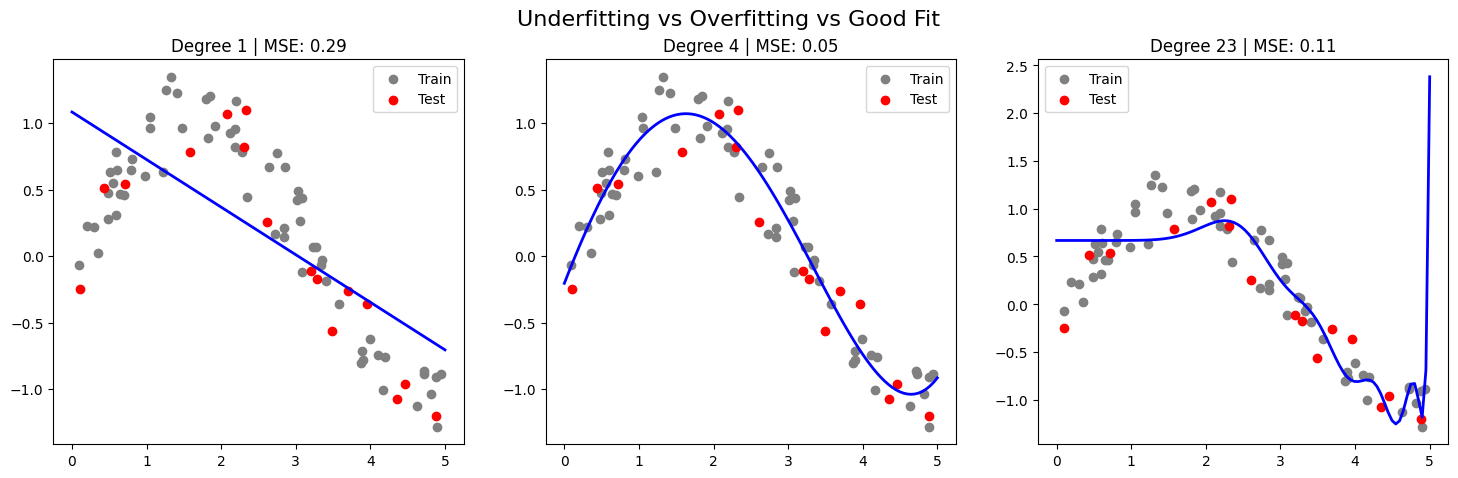

In [7]:
plt.figure(figsize=(18, 5))

for i, degree in enumerate(degrees,1):
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    
    # Plot
    plt.subplot(1, 3, i)
    plt.scatter(X_train, y_train, color='gray', label='Train')
    plt.scatter(X_test, y_test, color='red', label='Test')
    
    X_plot = np.linspace(0, 5, 100).reshape(-1, 1)
    y_plot = model.predict(X_plot)
    plt.plot(X_plot, y_plot, color='blue', linewidth=2)
    
    plt.title(f"Degree {degree} | MSE: {mse:.2f}")
    plt.legend()

plt.suptitle("Underfitting vs Overfitting vs Good Fit", fontsize=16)
plt.show()